In [27]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

In [28]:
df = pd.read_csv("thyroid_dataset.csv")

In [29]:
X = df.drop("Outlier_label" , axis = 1)
y = df["Outlier_label"]

In [30]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [39]:
isf = IsolationForest(
    n_estimators = 101,
    contamination =0.036,
    random_state = 42
)
labels = isf.fit_predict(X_scaled)

In [40]:
# Pca to visulatize
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

<function matplotlib.pyplot.show(close=None, block=None)>

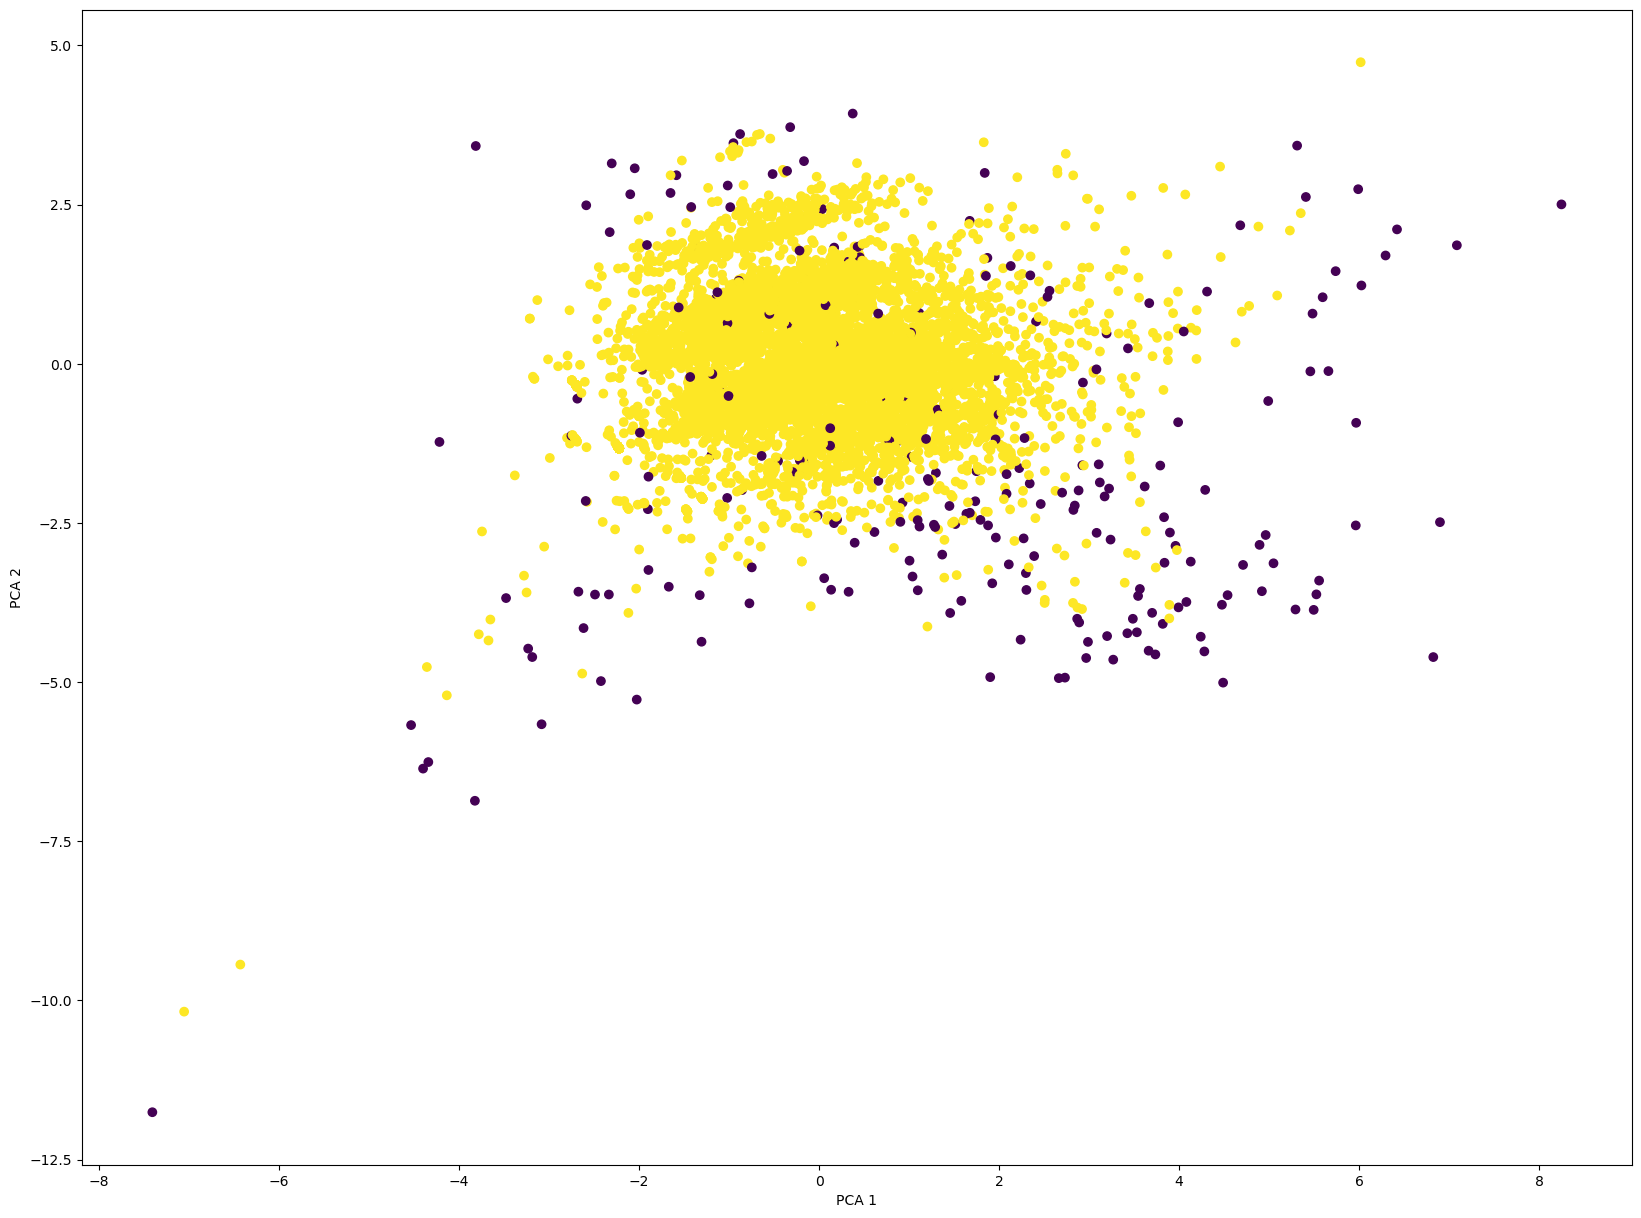

In [41]:
plt.figure(figsize = (20,15))
plt.scatter(X_pca[:,0] , X_pca[:,1] , c = labels)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [42]:
n_outliers = np.sum(labels == -1)
normal = np.sum(labels == 1)
print(f"Outliers : {n_outliers}")
print(f"Normal : {normal}")

Outliers : 249
Normal : 6667
